# Previsão de Rendimento de Safra — FarmTech Solutions

Uma fazenda de 200 hectares produz múltiplas culturas (cacau, palma, arroz, borracha). É necessário prever o **rendimento em toneladas/hectare** a partir das condições climáticas e de umidade registradas e, com isso, identificar padrões de produtividade (tendências e cenários discrepantes) para apoiar decisões de gestão agrícola.

**Base de dados:** `crop_yield.csv` — histórico de precipitação, umidade específica e relativa, temperatura e rendimento por cultura.

## 1. Importação de Bibliotecas

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Modelos e Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone

# Algoritmos de Regressão
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor


# Configurações Visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento e Analise inicial da base

In [44]:
# Carregamento da base
df = pd.read_csv('data/crop_yield.csv')

# Shape: linhas e colunas
display(df.info())

# Head
display(
    df.head())
print()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


None

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


### 2.1 Análise Variaveis Climaticas

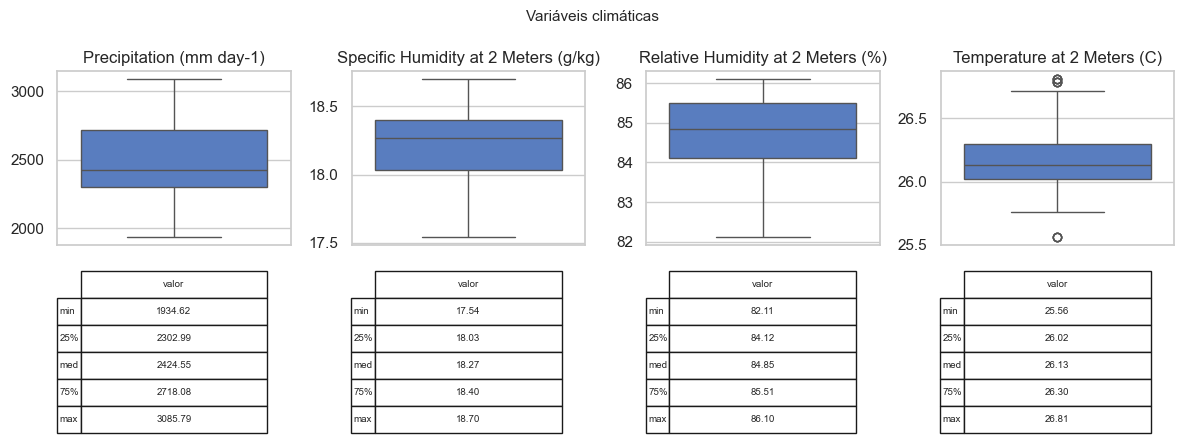

In [45]:
vars_clima = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
              'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
fig = plt.figure(figsize=(12, 4.5))
gs = fig.add_gridspec(2, 4, height_ratios=[0.6, 0.5])
fig.suptitle('Variáveis climáticas', fontsize=11)
for i, col in enumerate(vars_clima):
    ax = fig.add_subplot(gs[0, i])
    sns.boxplot(ax=ax, data=df, y=col)
    ax.set_title(col)
    ax.set_ylabel('')
    ax_tab = fig.add_subplot(gs[1, i])
    ax_tab.axis('off')
    v = df[col]
    cell_text = [[f"{v.min():.2f}"], [f"{v.quantile(0.25):.2f}"], [f"{v.median():.2f}"], [f"{v.quantile(0.75):.2f}"], [f"{v.max():.2f}"]]
    row_lbl = ['min', '25%', 'med', '75%', 'max']
    t = ax_tab.table(cellText=cell_text, rowLabels=row_lbl, colLabels=['valor'], loc='center', cellLoc='center')
    t.auto_set_font_size(False)
    t.set_fontsize(7)
    t.scale(0.8, 1.6)
plt.tight_layout()
plt.show()


Pontos observados:

_ Variaveis climaticas se repetem em cada cultura por se tratar de dados do ambiente, por isso observamos apenas 1 vez cada uma.

_ Na precipitacao temos uma alta variabilidade. Como as chuvas nao sao constantes, podemos ter periodos de secas e alta precipitacao na mesma safra.

_ Na umidade (especifica e relativa) temos uma certa estabilidade. 

_ Na temperatura tambem temos uma estabilidade com IQC de apenas 0,28 °C.

### 2.2 Análise da Variavel Produtividade

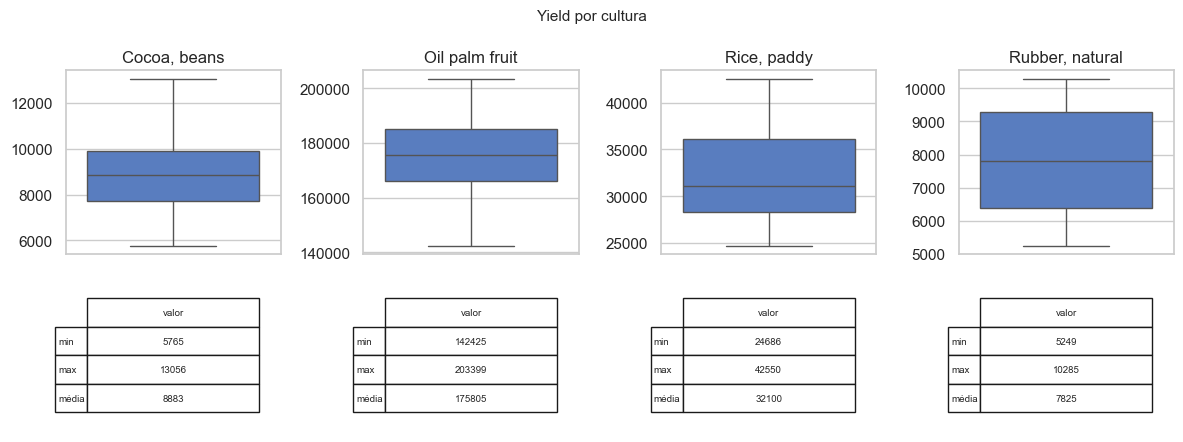

In [46]:

fig2 = plt.figure(figsize=(12, 4.5))
gs2 = fig2.add_gridspec(2, 4, height_ratios=[0.6, 0.5])
fig2.suptitle('Yield por cultura', fontsize=11)
for i, crop in enumerate(df['Crop'].unique()):
    ax = fig2.add_subplot(gs2[0, i])
    df_crop = df[df['Crop'] == crop]
    sns.boxplot(ax=ax, data=df_crop, y='Yield')
    ax.set_title(crop)
    ax.set_ylabel('')
    ax_tab = fig2.add_subplot(gs2[1, i])
    ax_tab.axis('off')
    v = df_crop['Yield']
    cell_text = [[f"{v.min():.0f}"], [f"{v.max():.0f}"], [f"{v.mean():.0f}"]]
    row_lbl = ['min', 'max', 'média']
    t = ax_tab.table(cellText=cell_text, rowLabels=row_lbl, colLabels=['valor'], loc='center', cellLoc='center')
    t.auto_set_font_size(False)
    t.set_fontsize(7)
    t.scale(0.8, 1.6)
plt.tight_layout()
plt.show()

Pontos observados:

_ Palma tem rendimento bem maior que cacau e borracha; arroz fica entre essas faixas.

_ A variacao de Yeld das culturas indica sensibilidade alta, sendo Rubber a cultura de maior variacao. Se essa variacao for influenciada por algum fator climatico, vamos conseguir verificar adiante na analise. 


### 2.3 Validação e identificação de outliers

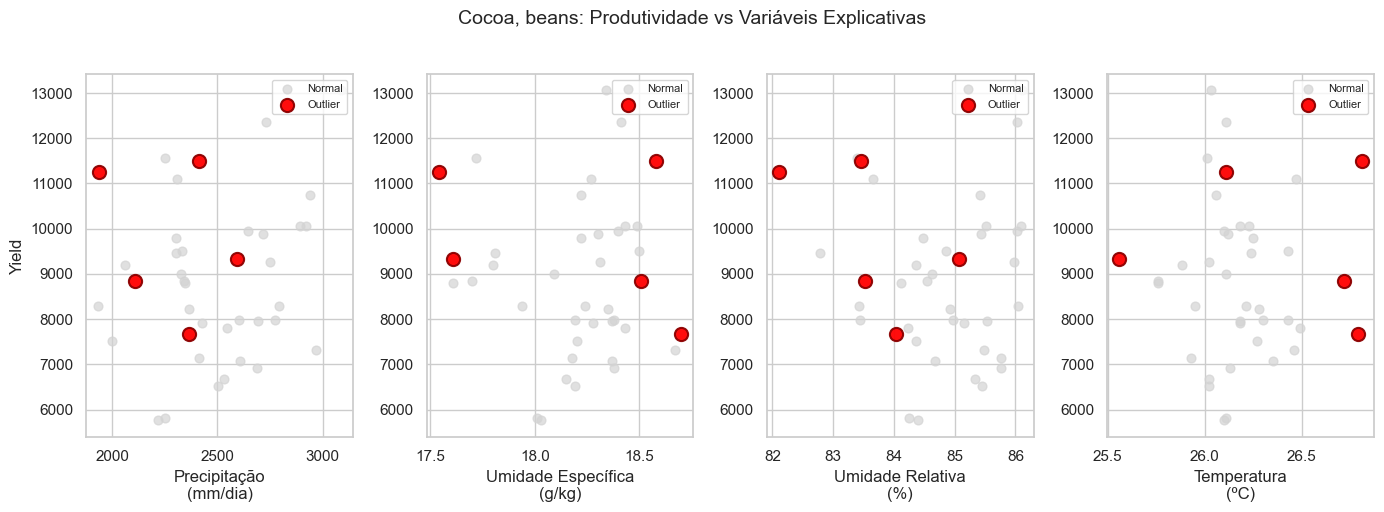

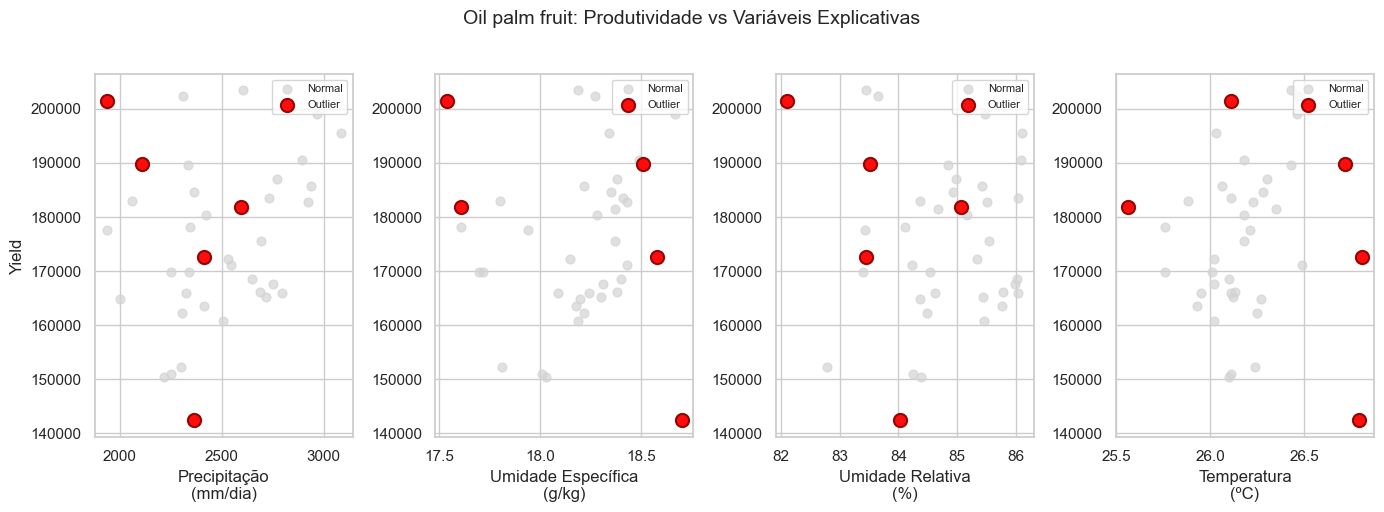

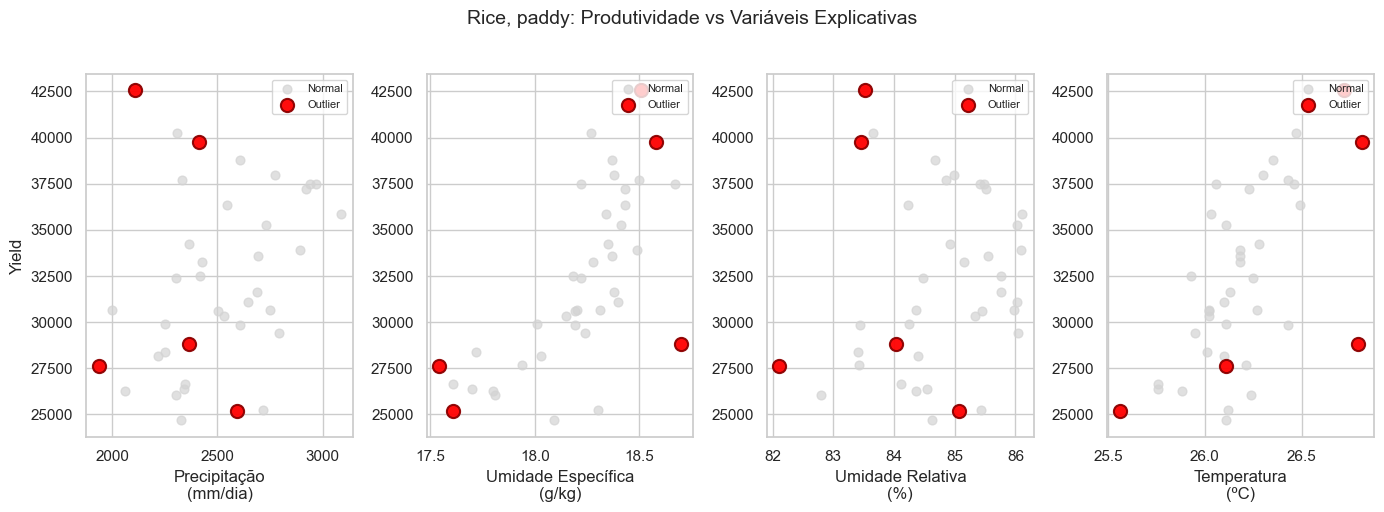

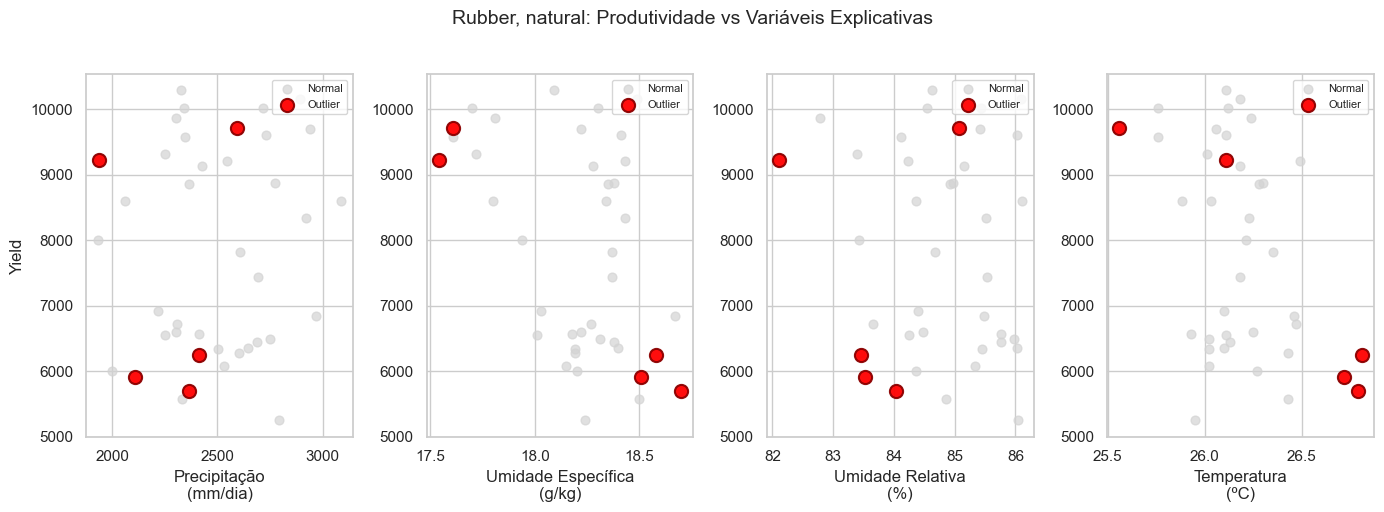

RESUMO DA ANÁLISE DE OUTLIERS
• Cocoa, beans: 5/39 outliers (12.8%)
• Oil palm fruit: 5/39 outliers (12.8%)
• Rice, paddy: 5/39 outliers (12.8%)
• Rubber, natural: 5/39 outliers (12.8%)

Total geral: 20/156 registros (12.8%)


In [47]:
# Método IQR por cultura (1.5 * IQR calculados dentro de cada Crop)
cols_num = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
            'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']

outlier_cols = {col: pd.Series(False, index=df.index) for col in cols_num}
resumo_culturas = []

for crop in df['Crop'].unique():
    mask_crop = df['Crop'] == crop
    crop_outlier_mask = pd.Series(False, index=df.index)
    for col in cols_num:
        vals = df.loc[mask_crop, col]
        Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
        IQR = Q3 - Q1
        lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        out_mask = mask_crop & ((df[col] < lb) | (df[col] > ub))
        outlier_cols[col] = outlier_cols[col] | out_mask
        crop_outlier_mask = crop_outlier_mask | out_mask
    resumo_culturas.append((crop, crop_outlier_mask.sum(), mask_crop.sum()))

# Marcar coluna outlier no df (para uso posterior na modelagem)
df['outlier'] = pd.concat(outlier_cols, axis=1).any(axis=1)
df_out = df[df['outlier']].copy()
df_out['Motivo'] = df_out.index.map(lambda i: ', '.join([col for col in cols_num if outlier_cols[col].loc[i]]))

# Pair plot: Yield vs variáveis explicativas
vars_explic = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
               'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
labels_x = ['Precipitação\n(mm/dia)', 'Umidade Específica\n(g/kg)', 'Umidade Relativa\n(%)', 'Temperatura\n(ºC)']

for crop in df['Crop'].unique():
    df_plot = df[df['Crop'] == crop][vars_explic + ['Yield', 'outlier']].copy()
    df_n = df_plot[~df_plot['outlier']]
    df_o = df_plot[df_plot['outlier']]
    fig, axes = plt.subplots(1, 4, figsize=(14, 5))
    for j, (col, lab) in enumerate(zip(vars_explic, labels_x)):
        ax = axes[j]
        ax.scatter(df_n[col], df_n['Yield'], c='lightgray', s=40, alpha=0.7, label='Normal')
        if len(df_o) > 0:
            ax.scatter(df_o[col], df_o['Yield'], c='red', s=90, alpha=0.95, edgecolors='darkred', linewidths=1.5, label='Outlier', zorder=5)
        ax.set_xlabel(lab)
        ax.set_ylabel('Yield' if j == 0 else '')
        ax.legend(loc='upper right', fontsize=8)
    fig.suptitle(f'{crop}: Produtividade vs Variáveis Explicativas', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# Resumo da análise
print("RESUMO DA ANÁLISE DE OUTLIERS")
for crop, n_out, n_total in resumo_culturas:
    pct = 100 * n_out / n_total if n_total > 0 else 0
    print(f"• {crop}: {n_out}/{n_total} outliers ({pct:.1f}%)")
print(f"\nTotal geral: {df['outlier'].sum()}/{len(df)} registros ({100*df['outlier'].sum()/len(df):.1f}%)")

Pontos observados:

_ No grafico podemos identificar os outliers que nao aparentam sem erro de registro, entao devemos mante-lo e gerar uma analise com e sem outlier para podermos comparar posteriormente.

### 2.4 Análise de Correlação

Verificamos a correlação entre as variáveis numéricas para entender a estrutura dos dados e identificar possíveis redundâncias (multicolinearidade). Esta informação será útil na etapa de modelagem (bloco 4).

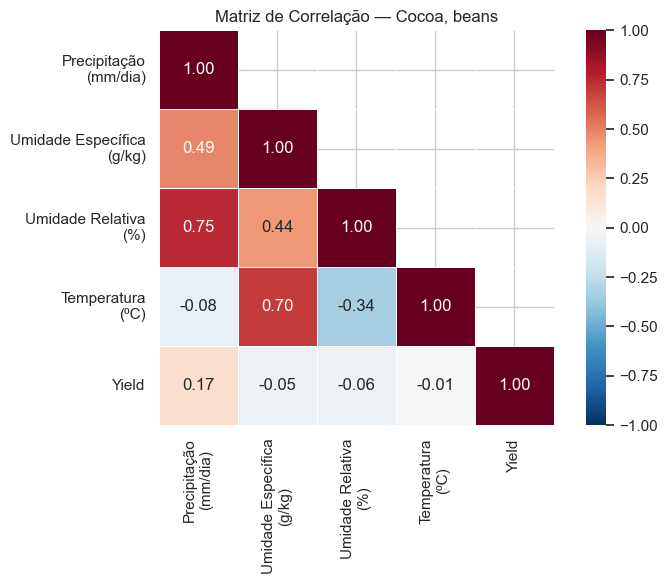

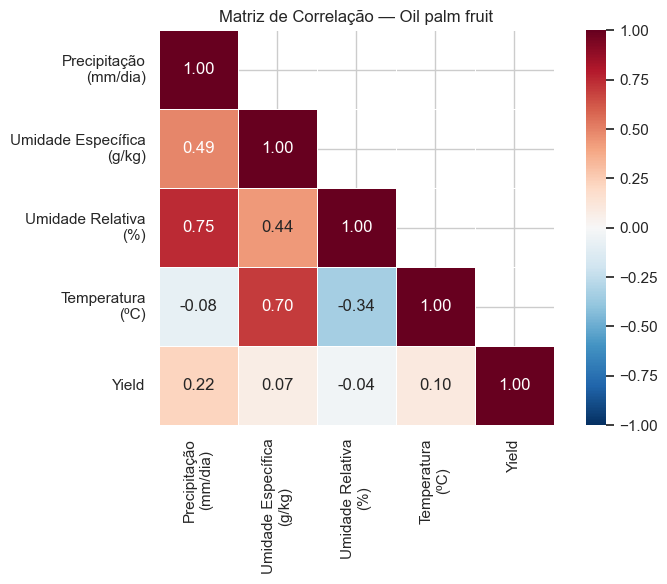

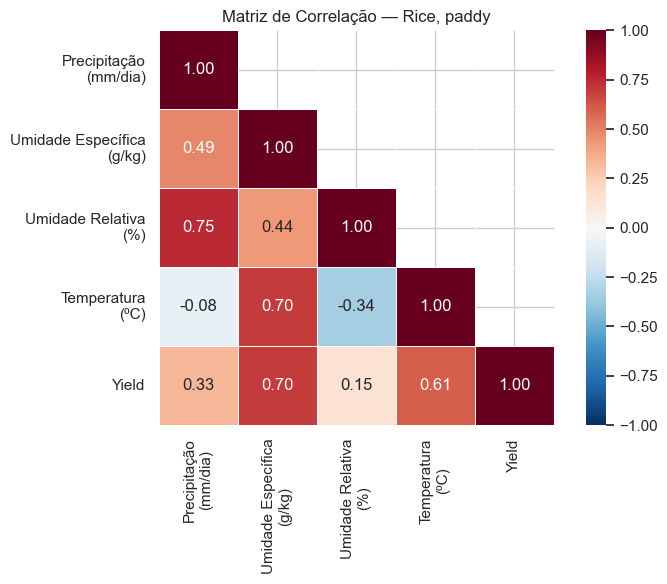

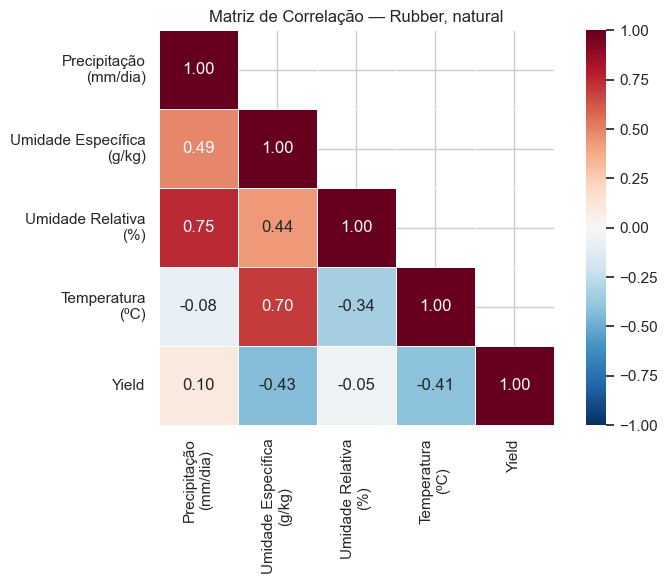

In [48]:
# Heatmap de correlação das variáveis numéricas
cols_corr = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
             'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']
labels_corr = {'Precipitation (mm day-1)': 'Precipitação\n(mm/dia)',
               'Specific Humidity at 2 Meters (g/kg)': 'Umidade Específica\n(g/kg)',
               'Relative Humidity at 2 Meters (%)': 'Umidade Relativa\n(%)',
               'Temperature at 2 Meters (C)': 'Temperatura\n(ºC)',
               'Yield': 'Yield'}

# Heatmap por cultura
for crop in df['Crop'].unique():
    df_crop = df[df['Crop'] == crop][cols_corr]
    corr_crop = df_crop.corr().rename(index=labels_corr, columns=labels_corr)
    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_crop, dtype=bool), k=1)
    sns.heatmap(corr_crop, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, vmin=-1, vmax=1)
    plt.title(f'Matriz de Correlação — {crop}')
    plt.tight_layout()
    plt.show()


Pontos observados:

Cocoa, beans: apenas precipitacao mostra leve correlacao positiva com Yield. Há forte relacao entre Precipitação × Umidade relativa e Umidade específica × Temperatura.

Oil palm fruit: apenas precipitacao mostra leve correlacao positiva com Yield. Há forte relacao entre Precipitação × Umidade relativa e Umidade específica × Temperatura.

Rice, paddy: umidade específica e temperatura explicam bem parte da variação de Yield. Relacao moderada com precipitacao tambem. Há forte relacao entre Precipitação × Umidade relativa e Umidade específica × Temperatura.

Rubber, natural: cultura com correlacoes negativas fortes onde mais umidade específica e temperatura sao associadas a menor Yield. Há forte relacao entre Precipitação × Umidade relativa e Umidade específica × Temperatura. Ha relacao moderada entre Precipitação × Umidade específica e Umidade específica × Umidade relativa.

Conclusão: rice responde positivamente a umidade e temperatura; rubber responde negativamente; cocoa e oil palm têm relações fracas. Creio que seja fundamental uma analise de PCA para evitar multiconialidade entre as variaveis explicativas.

## 3. Clusterização e Tendências (Não-Supervisionado)

Aplicaremos **K-Means** para segmentar as plantações e encontrar padrões de produtividade (rendimento × clima). A clusterização é feita **por cultura**, identificando subgrupos (ex.: baixo/médio/alto rendimento) dentro de cada uma.

### 3.1 Seleção de features e padronização (por cultura)

A clusterização será feita **dentro de cada cultura**, identificando algo proximo aos subgrupos de produtividade (ex.: baixo/médio/alto rendimento) em cada uma.

Foco em Precipitação, Temperatura e Yield (variáveis com maior variabilidade e relevância para produtividade)

In [49]:
# Variáveis que melhor explicam Yield por cultura (|r| >= 0.15 com Yield, até 2 vars)
vars_explic = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
               'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
labels_vars = {'Precipitation (mm day-1)': 'Precipitação\n(mm/dia)',
               'Specific Humidity at 2 Meters (g/kg)': 'Umidade Específica\n(g/kg)',
               'Relative Humidity at 2 Meters (%)': 'Umidade Relativa\n(%)',
               'Temperature at 2 Meters (C)': 'Temperatura\n(ºC)'}

features_per_crop = {}
for crop in df['Crop'].unique():
    dc = df[df['Crop'] == crop][vars_explic + ['Yield']]
    corr = dc.corr()['Yield'].drop('Yield')
    corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
    best = [v for v in corr.index if abs(corr[v]) >= 0.15][:2]
    features_per_crop[crop] = best if best else [corr.index[0]]  # fallback: variável com maior |r|

df['Cluster'] = -1

### 3.2 Escolha do número de clusters (K) por cultura — Método do Cotovelo + Silhouette

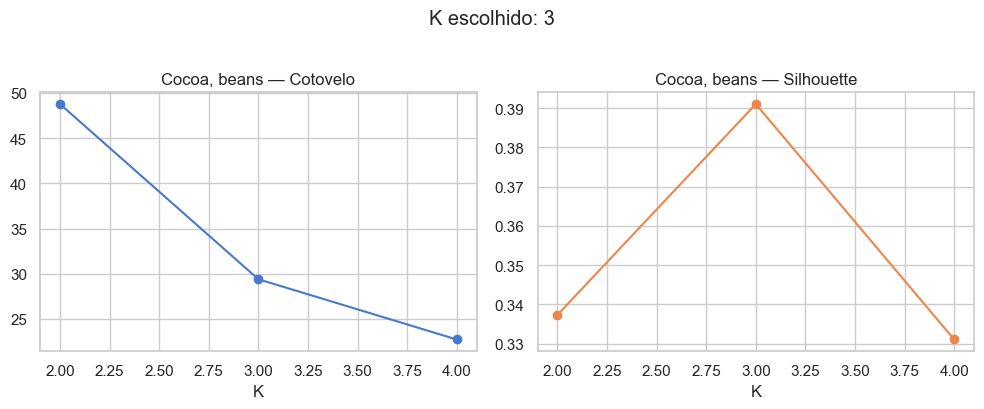

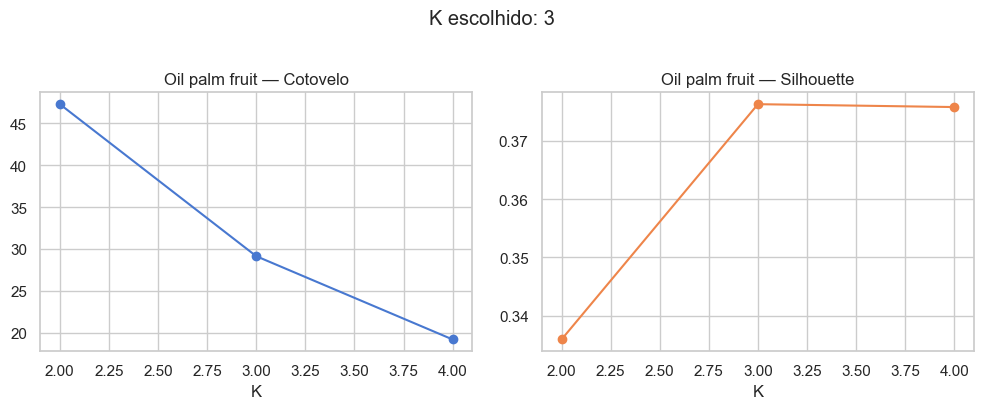

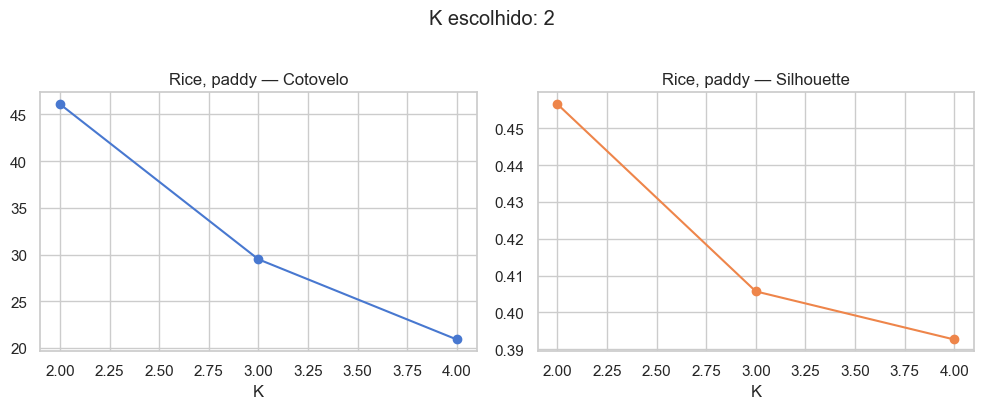

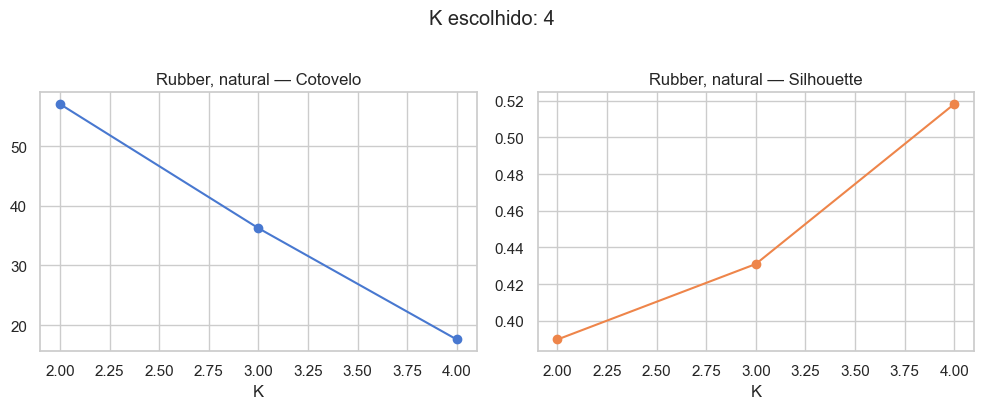

In [64]:
# Por cultura: PCA (reduz multicorrelação) + cotovelo + silhouette (k=2 a 5)
k_range = range(2, 5)
k_per_crop = {}
pca_per_crop = {}
scaler_per_crop = {}

for crop in df['Crop'].unique():
    feat = features_per_crop[crop] + ['Yield']
    df_c = df[df['Crop'] == crop][feat]
    scaler = StandardScaler()
    X_c = scaler.fit_transform(df_c)
    pca = PCA(n_components=0.9, random_state=42).fit(X_c)
    X_pca = pca.transform(X_c)
    scaler_per_crop[crop] = scaler
    pca_per_crop[crop] = pca
    inertia, silhouettes = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42).fit(X_pca)
        inertia.append(km.inertia_)
        silhouettes.append(silhouette_score(X_pca, km.labels_))
    k_per_crop[crop] = np.argmax(silhouettes) + 2  # K indicado pelo Silhouette (maior score)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(list(k_range), inertia, marker='o')
    axes[0].set_title(f'{crop} — Cotovelo')
    axes[0].set_xlabel('K')
    axes[1].plot(list(k_range), silhouettes, marker='o', color='C1')
    axes[1].set_title(f'{crop} — Silhouette')
    axes[1].set_xlabel('K')
    plt.suptitle(f'K escolhido: {k_per_crop[crop]}', y=1.02)
    plt.tight_layout()
    plt.show()

**Pontos observados:**

Aplicamos **PCA** (retendo ~90% da variância) antes do K-Means para reduzir multicorrelação entre variáveis (ex.: Umidade específica e Temperatura em Rice), decorrelacionando os dados e melhorando a interpretação dos clusters.

*Cocoa, beans* — K = 3
Cotovelo: Queda forte de K=2 para K=3; depois o ganho de redução de inércia diminui, indicando cotovelo em torno de K=3.
Silhouette: Máximo em K=3 (~0,38), acima de K=2 (~0,275) e K=4 (~0,36).
Conclusão: K=3 é bem suportado pelos dois critérios.

*Oil palm fruit* — K = 3
Cotovelo: Queda acentuada até K=3; após isso a curva se achata e o ganho é menor.
Silhouette: Maior valor em K=3 (~0,385), com queda em K=4 (~0,375) e K=5 (~0,32).
Conclusão: K=3 é bem suportado pelos dois critérios.

*Rice, paddy* — K = 2
Cotovelo: Pode sugerir K=3 (onde o “joelho” da curva é mais visível).
Silhouette: Silhouette máximo em K=2 (~0,41), com queda em K=3 (~0,38) e valores menores para K=4 e K=5.
Conclusão: K=2 está correto, pois o critério usado é o Silhouette, e ele claramente indica K=2 como melhor opção

*Rubber, natural* — K = 4
Cotovelo: O cotovelo é razoavelmente bem definido em K=3-4; após isso a curva se achata.
Silhouette: O Silhouette máximo está em K=4 (~0,44); K=3 (~0,37) é menor.
Conclusão: K=4 é a escolha correta, pois seguimos o indicador Silhouette (maior score). Não há mais limite artificial de K; o número de clusters segue as ferramentas de análise.

### 3.3 Aplicação do K-Means e visualização dos clusters

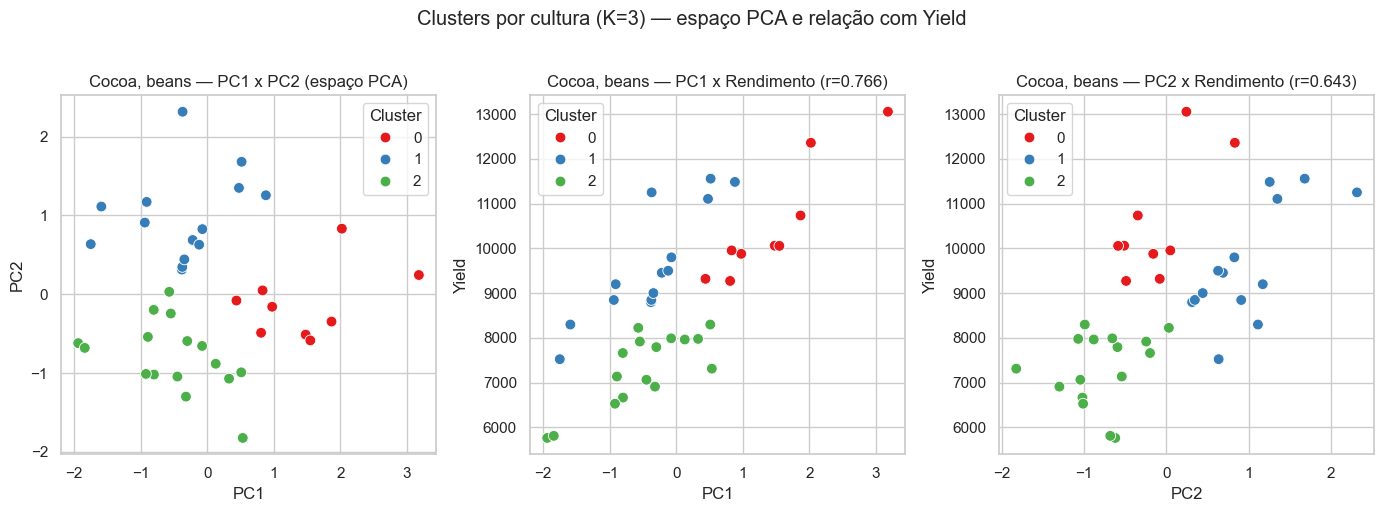

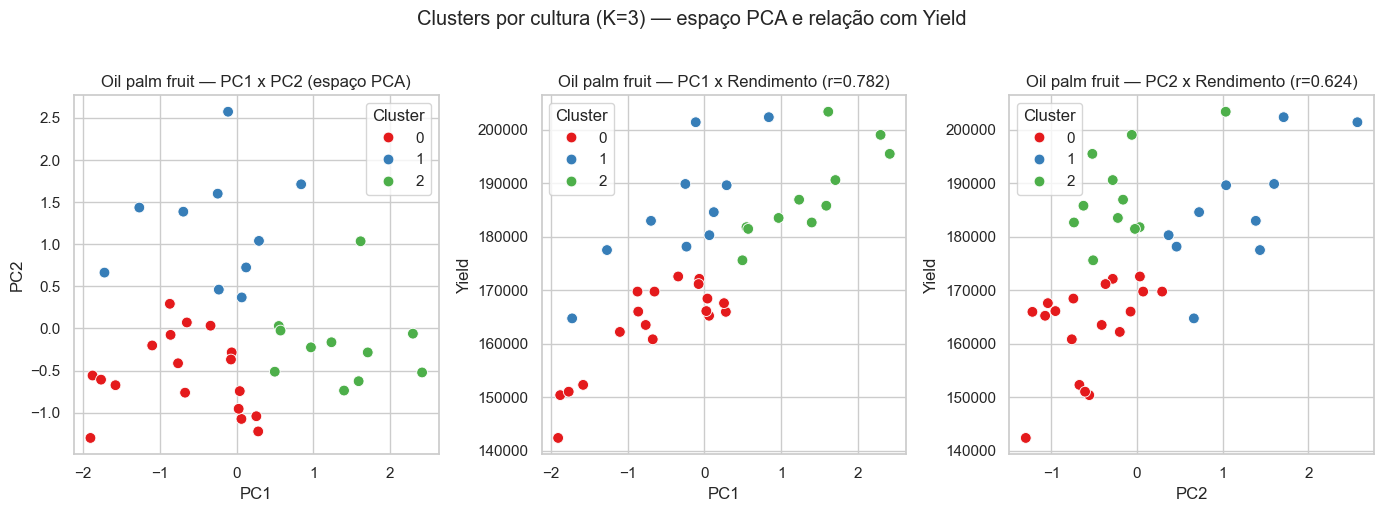

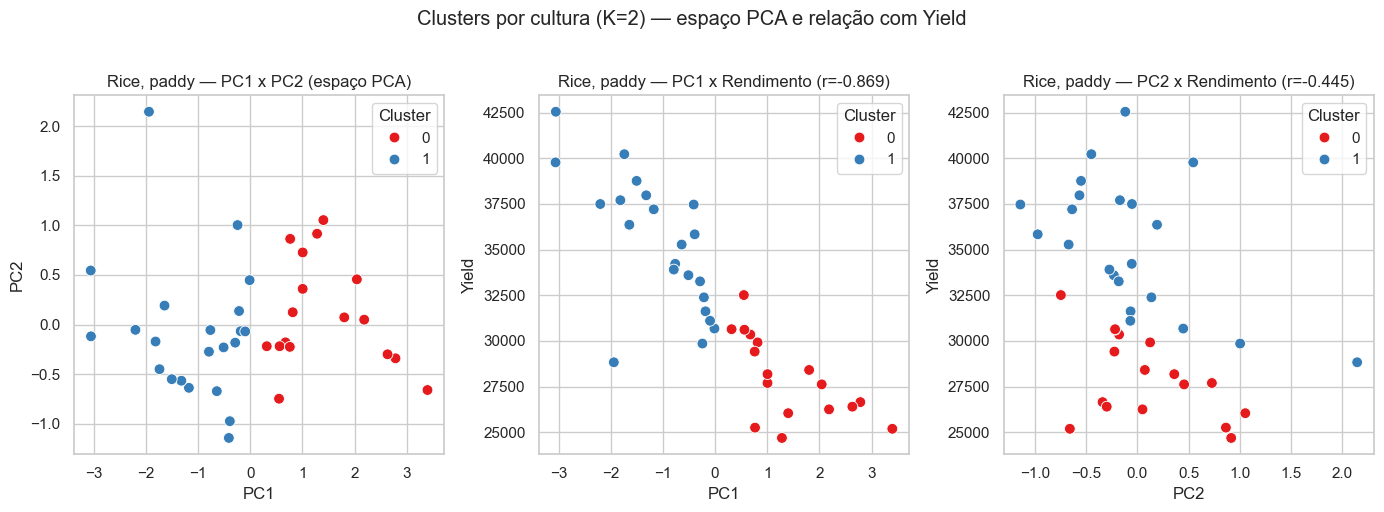

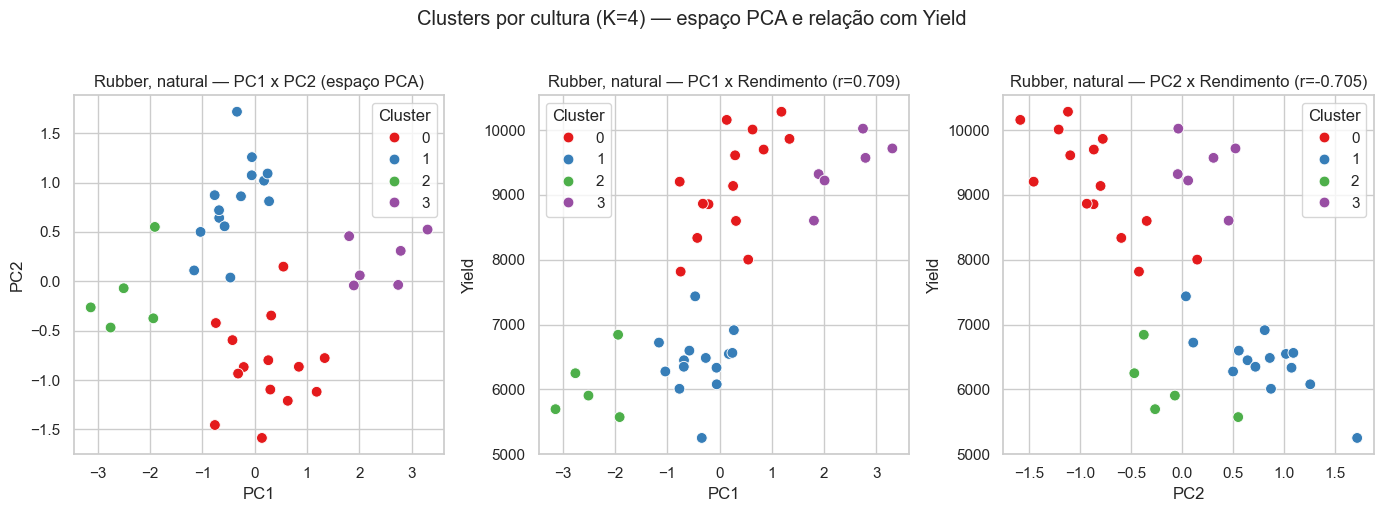

In [65]:
# K-Means por cultura (em espaço PCA) e visualização
for crop in df['Crop'].unique():
    mask = df['Crop'] == crop
    feat = features_per_crop[crop] + ['Yield']
    df_c = df.loc[mask, feat]
    scaler = scaler_per_crop[crop]
    pca = pca_per_crop[crop]
    X_c = scaler.transform(df_c)
    X_pca = pca.transform(X_c)
    k = k_per_crop[crop]
    km = KMeans(n_clusters=k, random_state=42).fit(X_pca)
    df.loc[mask, 'Cluster'] = km.labels_

# Gráficos: PC1 x PC2 (espaço PCA), PC1 x Yield e PC2 x Yield (correlação no título)
for crop in df['Crop'].unique():
    mask = df['Crop'] == crop
    feat = features_per_crop[crop] + ['Yield']
    df_c = df.loc[mask, feat]
    X_pca = pca_per_crop[crop].transform(scaler_per_crop[crop].transform(df_c))
    df_viz = df[df['Crop'] == crop].copy()
    df_viz['PC1'] = X_pca[:, 0]
    df_viz['PC2'] = X_pca[:, 1] if X_pca.shape[1] > 1 else np.zeros(len(df_viz))
    corr_pc1 = df_viz['PC1'].corr(df_viz['Yield'])
    corr_pc2 = df_viz['PC2'].corr(df_viz['Yield'])
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    sns.scatterplot(data=df_viz, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=60, ax=axes[0])
    axes[0].set_title(f'{crop} — PC1 x PC2 (espaço PCA)')
    sns.scatterplot(data=df_viz, x='PC1', y='Yield', hue='Cluster', palette='Set1', s=60, ax=axes[1])
    axes[1].set_title(f'{crop} — PC1 x Rendimento (r={corr_pc1:.3f})')
    sns.scatterplot(data=df_viz, x='PC2', y='Yield', hue='Cluster', palette='Set1', s=60, ax=axes[2])
    axes[2].set_title(f'{crop} — PC2 x Rendimento (r={corr_pc2:.3f})')
    plt.suptitle(f'Clusters por cultura (K={k_per_crop[crop]}) — espaço PCA e relação com Yield', y=1.02)
    plt.tight_layout()
    plt.show()

In [66]:
# Tabela de características médias de cada cluster — uma por cultura
for crop in df['Crop'].unique():
    df_c = df[df['Crop'] == crop]
    tab = df_c.groupby('Cluster').agg(
        n=('Yield', 'count'),
        Precip_media=('Precipitation (mm day-1)', 'mean'),
        Temp_media=('Temperature at 2 Meters (C)', 'mean'),
        Yield_media=('Yield', 'mean')
    ).round(2)
    tab['Yield_media'] = tab['Yield_media'].astype(int)
    tab = tab.rename(columns={'Precip_media': 'Precip (média)', 'Temp_media': 'Temp (°C média)', 'Yield_media': 'Yield (média)'})
    print(f"\n{crop} (K={len(tab)})")
    display(tab)


Cocoa, beans (K=3)


,n,Precip (média),Temp (°C média),Yield (média)
Cluster,,,,
0,9,2808.50,26.05,10522
1,14,2211.37,26.22,9621
2,16,2546.11,26.23,7315



Oil palm fruit (K=3)


,n,Precip (média),Temp (°C média),Yield (média)
Cluster,,,,
0,18,2463.90,26.16,163219
1,10,2181.84,26.23,185182
2,11,2800.45,26.17,187873



Rice, paddy (K=2)


,n,Precip (média),Temp (°C média),Yield (média)
Cluster,,,,
0,17,2368.65,25.99,27988
1,22,2577.56,26.33,35276



Rubber, natural (K=4)


,n,Precip (média),Temp (°C média),Yield (média)
Cluster,,,,
0,14,2611.65,26.21,9175
1,14,2478.71,26.14,6428
2,5,2436.63,26.64,6051
3,6,2254.22,25.85,9410


**Pontos observados — clusters, médias e interpretação (relação com a realidade):**

_**Cocoa, beans (K=3):** Com base nas médias da tabela e na correlação PC1×Yield (r positivo): **Cluster de maior Yield** representa plantios em condições climáticas mais favoráveis (maior precipitação ~2.700–2.800 mm/dia, temp. ~26°C) — cenário de alta produtividade. **Cluster intermediário** tem precipitação e temp. médias um pouco distintas. **Cluster de menor Yield** associa-se a condições menos favoráveis (precipitação mais baixa ou perfil climático subótimo) — cenário de baixa produtividade, onde intervenções (irrigação, manejo) podem ter maior retorno._

_**Oil palm fruit (K=3):** Os três clusters separam claramente **alta**, **média** e **baixa produtividade**. O cluster de menor Yield tende a apresentar precipitação e temperatura médias que indicam condições menos favoráveis; o de maior Yield concentra o perfil climático mais benéfico. A escala de Yield é elevada (≈170–180 mil ton/ha), refletindo o alto potencial da cultura. O grupo de baixo rendimento representa áreas prioritárias para melhorias._

_**Rice, paddy (K=2):** A dicotomia é clara: **um cluster** com Yield médio mais alto (condições climáticas associadas a maior produtividade no arroz) e **outro** com Yield médio mais baixo. Em Rice, PC1 tem correlação negativa com Yield (r≈-0,87), ou seja, perfis com PC1 mais baixo tendem a maior rendimento. O cluster de maior Yield concentra condições de precipitação e temperatura médias que favorecem o arroz._

_**Rubber, natural (K=4):** Os quatro clusters permitem segmentação mais fina. Em Rubber, PC1 correlaciona positivamente com Yield e PC2 negativamente — condições de maior umidade/temperatura podem reduzir o rendimento. **Clusters de alto Yield** (tipicamente maiores valores de PC1, PC2 mais baixo): condições climáticas favoráveis para a borracha. **Clusters de baixo Yield**: perfil climático desfavorável (ex.: excesso de umidade ou temperatura). O grupo de menor rendimento representa as áreas que mais se beneficiam de ajustes no manejo ou na escolha de variedades._

## 4. Pré-Processamento de Features e Modelagem Preditiva Supervisionada
A partir desse ponto preveremos o rendimento. Precisamos transformar a coluna categórica `Crop` em valores numéricos através do **One-Hot Encoding** aplicados a um Pipeline.

In [67]:
# Variáveis Independentes (X) e Alvo (y)
X = df.drop(columns=['Yield', 'Cluster', 'outlier'])  # Cluster e outlier apenas descritivos
y = df['Yield']

# Identificando as colunas numéricas e a categórica
num_features = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 
               'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
cat_features = ['Crop']

# Transformador customizado para limpar e normatizar no Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ])

# Cenário 1: COM outliers (dados completos)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Cenário 2: SEM outliers
df_clean = df[~df['outlier']]
X_clean = df_clean.drop(columns=['Yield', 'Cluster', 'outlier'])
y_clean = df_clean['Yield']
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, shuffle=True)

print("Com outliers (dados completos):")
print(f"  Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")
print("Sem outliers:")
print(f"  Treino: {X_train_clean.shape[0]} | Teste: {X_test_clean.shape[0]}")

Com outliers (dados completos):
  Treino: 124 | Teste: 32
Sem outliers:
  Treino: 108 | Teste: 28


### 4.1 Treinamento de Modelos de Machine Learning
1. **Regressão Linear** (Base simples)
2. **Ridge** (Linear com regularização L2, reduz multicolinearidade)
3. **Decision Tree Regressor** (Mapeamento não linear)
4. **Random Forest** (Ensemble de múltiplas árvores)
5. **Extra Trees** (Árvores extremamente aleatórias)
6. **Gradient Boosting** (Árvores em sequência focadas no erro)
7. **XGBoost** (Gradient boosting otimizado)

In [68]:
# Dicionário contendo os modelos (SVR substituído por XGBoost; Ridge e Extra Trees adicionados)
models_dict = {
    "Regressão Linear": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

# Treinar e avaliar para cada cenário (com e sem outliers)
cenarios = [
    ("Com outliers", X_train, y_train, X_test, y_test),
    ("Sem outliers", X_train_clean, y_train_clean, X_test_clean, y_test_clean)
]

for titulo, X_tr, y_tr, X_te, y_te in cenarios:
    results = []
    for name, model in models_dict.items():
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', clone(model))])
        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_te)
        r2 = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae = mean_absolute_error(y_te, y_pred)
        results.append({'Modelo': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae})
    
    metrics_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
    print(f"\n{'='*60}\n{titulo} (Treino: {X_tr.shape[0]}, Teste: {X_te.shape[0]})\n{'='*60}")
    display(metrics_df.style.background_gradient(cmap='Greens', subset=['R2 Score']))


Com outliers (Treino: 124, Teste: 32)


,Modelo,R2 Score,RMSE,MAE
0,Extra Trees,0.995052,4381.157734,2712.877812
1,Regressão Linear,0.995022,4394.165819,3132.796384
2,Random Forest,0.993865,4878.304729,2797.345313
3,Árvore de Decisão,0.992714,5316.346746,3142.531250
4,Ridge,0.991076,5883.517077,4436.545012
5,Gradient Boosting,0.990536,6058.894234,3108.842605
6,XGBoost,0.988329,6728.469987,4082.617966



Sem outliers (Treino: 108, Teste: 28)


,Modelo,R2 Score,RMSE,MAE
0,Extra Trees,0.991305,7476.108798,5014.249643
1,Gradient Boosting,0.989674,8147.115646,5307.295771
2,XGBoost,0.988420,8627.586258,5261.715489
3,Random Forest,0.988272,8682.666653,5646.475000
4,Regressão Linear,0.987245,9054.732620,6161.118551
5,Ridge,0.980376,11231.300287,8418.167037
6,Árvore de Decisão,0.977616,11994.896689,6571.071429


**Pontos observados:**

_ *Extra Trees* manteve o melhor desempenho nos dois cenários (R²≈0,995 com outliers; 0,991 sem), com menor RMSE e MAE. É o modelo mais robusto e indicado para previsão de Yield.

_ *Com outliers:* Extra Trees > Regressão Linear > Random Forest > Árvore de Decisão > Ridge > Gradient Boosting > XGBoost. Todos com R² > 0,98.

_ *Sem outliers:* Os erros absolutos (RMSE, MAE) aumentam para todos os modelos. Ranking muda: Extra Trees > Gradient Boosting > XGBoost > Random Forest > Regressão Linear > Ridge > Árvore de Decisão. Extra Trees, GB e XGBoost mantêm desempenho elevado; modelos lineares e Árvore de Decisão caem mais.

_ *Treinamento por cultura:* mesmo com os bons resultados acima me pergunto se faz sentido realizar o treinametno por cultura, pois cada uma (Cocoa, Oil palm, Rice, Rubber) tem relação distinta com clima (ex.: Rubber com correlação negativa). Porém, com ~39 amostras por cultura, o risco de overfitting é alto. A abordagem atual ja usa o `Crop` como feature, permitindo que o modelo capture efeitos por cultura. Uma alternativa seria testar modelagem por cultura em cenários com mais dados.

### 4.2 Simulador de produtividade por cultura

Informe os valores das variáveis climáticas abaixo. O modelo (Extra Trees treinado em 4.1) vai estimar o rendimento para cada cultura nessas condições e indicará qual cultura tem a melhor produtividade prevista para esse contexto.

In [69]:
# ========== EDITE OS VALORES ABAIXO ==========
precipitacao = 2500.0      # mm/dia
umidade_especifica = 18.0 # g/kg
umidade_relativa = 85.0    # %
temperatura = 26.0         # °C
# ===========================================

# Treinar pipeline Extra Trees (mesmo do 4.1) e prever para cada cultura
pipe_simul = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', ExtraTreesRegressor(n_estimators=100, random_state=42))])
pipe_simul.fit(X_train, y_train)

# Montar entrada para cada cultura (mesmas condições climáticas)
entradas = []
for crop in df['Crop'].unique():
    entradas.append({
        'Precipitation (mm day-1)': precipitacao,
        'Specific Humidity at 2 Meters (g/kg)': umidade_especifica,
        'Relative Humidity at 2 Meters (%)': umidade_relativa,
        'Temperature at 2 Meters (C)': temperatura,
        'Crop': crop
    })
df_entrada = pd.DataFrame(entradas)

# Prever rendimento para cada cultura
y_prev = pipe_simul.predict(df_entrada)
resultado = pd.DataFrame({
    'Cultura': df_entrada['Crop'].values,
    'Rendimento previsto (ton/ha)': y_prev.round(0).astype(int)
}).sort_values('Rendimento previsto (ton/ha)', ascending=False)

melhor = resultado.iloc[0]
print(f"Condições: Precip={precipitacao} mm/dia | Umidade esp.={umidade_especifica} g/kg | Umidade rel.={umidade_relativa}% | Temp={temperatura}°C\n")
print("Rendimento previsto por cultura:")
display(resultado)
print(f"\n► Melhor cultura para este contexto: {melhor['Cultura']} (rendimento estimado: {melhor['Rendimento previsto (ton/ha)']:,.0f} ton/ha)")

Condições: Precip=2500.0 mm/dia | Umidade esp.=18.0 g/kg | Umidade rel.=85.0% | Temp=26.0°C

Rendimento previsto por cultura:


,Cultura,Rendimento previsto (ton/ha)
1,Oil palm fruit,164156
2,"Rice, paddy",28071
0,"Cocoa, beans",7122
3,"Rubber, natural",6957



► Melhor cultura para este contexto: Oil palm fruit (rendimento estimado: 164,156 ton/ha)


## 5. Conclusões e Achados do Notebook

### Bloco 1 — Importação e configuração
Utilizamos pandas, matplotlib, seaborn e scikit-learn para análise e modelagem. O pipeline inclui PCA (clusterização), K-Means, múltiplos regressores (Linear, Ridge, árvores, ensembles) e métricas (R², RMSE, MAE). A base de trabalho foi `crop_yield.csv`.

### Bloco 2 — Carregamento e análise exploratória
A base tem **156 registros** e **4 culturas** (Cocoa, Oil palm, Rice, Rubber), com variáveis climáticas e Yield. 
A precipitação é a mais variável; umidade e temperatura são mais estáveis. A palma apresenta os maiores rendimentos; borracha, a maior variação. Foram identificados **outliers pelo método IQR**, mantidos para permitir análise com e sem exclusão. Na correlação por cultura, Rice responde positivamente a umidade e temperatura; Rubber, negativamente; Cocoa e Oil palm têm relações fracas. A multicolinearidade (ex.: Umidade específica × Temperatura) motivou o uso de PCA no bloco seguinte.

### Bloco 3 — Clusterização (PCA + K-Means)
O **PCA** (≈90% da variância) foi usado para reduzir multicorrelação antes do K-Means. A clusterização foi feita **por cultura**, com K escolhido por Silhouette (Cocoa e Oil palm: K=3; Rice: K=2; Rubber: K=4). **PC1** é o principal indicador de produtividade; PC2 contribui de forma complementar (às vezes inversa). Os clusters separam bem grupos de baixo, médio e alto rendimento em todas as culturas, permitindo segmentar plantações para gestão diferenciada.

### Bloco 4 — Modelagem preditiva e simulador
Treinamos **7 modelos** (Regressão Linear, Ridge, Árvore de Decisão, Random Forest, Extra Trees, Gradient Boosting, XGBoost), avaliados **com e sem outliers**. **Extra Trees** foi o melhor (R²≈0,995 com outliers; 0,991 sem), seguido por Random Forest e Regressão Linear. Modelos baseados em árvores e ensembles mostraram maior robustez à remoção de outliers. O **bloco 4.2** é um simulador: o usuário informa condições climáticas e o modelo indica a produtividade prevista para cada cultura e qual é a mais indicada para aquele contexto, apoiando decisões de plantio.